# TCC Damaris | Entrega 6 | Modelagem preditiva

Execução do protocolo congelado na seção de material e métodos do artigo. Este caderno produz a
seção **Desempenho dos modelos de aprendizado de máquina**.

Entradas esperadas em `04_modelagem`:

- `camada_a_wrangled.parquet`, gerado pela entrega 3

Saídas em `05_figuras` e `05_tabelas`, numeradas a partir da Figura 13 e da Tabela 11, para
continuar a sequência do caderno de analytics.

Regras do protocolo, todas fixadas antes de qualquer métrica de teste ser observada:

1. Alvo em horizonte de dois exercícios, `y_rj_h2`
2. Dez preditoras escolhidas por fundamento teórico, com filtro de correlação de 0,95
3. Partição temporal, nunca aleatória
4. Amostra pareada de um evento para três controles no treino, sem geração sintética
5. Conjunto de teste preservado em prevalência natural
6. Ganho inferior a 0,03 de AUC sobre o Z'' de Altman é equivalência prática

In [1]:
!pip install -q pandas numpy matplotlib scipy scikit-learn openpyxl pyarrow
!pip install -q xgboost shap

In [2]:
import json
import warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (roc_auc_score, roc_curve, average_precision_score,
                             precision_recall_curve, confusion_matrix, f1_score)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 220)

try:
    from xgboost import XGBClassifier
    TEM_XGB = True
except Exception:
    from sklearn.ensemble import HistGradientBoostingClassifier
    TEM_XGB = False

try:
    import shap
    TEM_SHAP = True
except Exception:
    TEM_SHAP = False

print("xgboost disponivel:", TEM_XGB)
print("shap disponivel:", TEM_SHAP)

xgboost disponivel: True
shap disponivel: True


## 1. Configuração visual e de saída

In [3]:
FONTE = "Arial"
disponiveis = {f.name for f in mpl.font_manager.fontManager.ttflist}
if FONTE not in disponiveis:
    print(f"ATENCAO: {FONTE} nao encontrada. Figuras sairao com a fonte padrao.")
    FONTE = mpl.rcParams["font.family"][0]
else:
    print(f"{FONTE} disponivel")

mpl.rcParams.update({
    "font.family": FONTE,
    "font.size": 12,
    "axes.titlesize": 12,
    "axes.labelsize": 12,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.dpi": 110,
    "savefig.dpi": 300,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": "#52514e",
    "axes.labelcolor": "#0b0b0b",
    "text.color": "#0b0b0b",
    "xtick.color": "#52514e",
    "ytick.color": "#52514e",
    "grid.color": "#e6e5e1",
    "grid.linewidth": 0.8,
    "legend.frameon": False,
})

AZUL, LARANJA, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
CINZA, CINZA_CLARO = "#52514e", "#c3c2b7"
DIV_NEG, DIV_NEUTRO, DIV_POS = "#2a78d6", "#f0efec", "#d03b3b"
print("paleta definida")

Arial disponivel
paleta definida


In [4]:
RAIZ = Path(r"G:\Meu Drive\TCC\Damaris Rebeca")
DIR_MODELAGEM = RAIZ / "04_modelagem"
DIR_FIG = RAIZ / "05_figuras"
DIR_TAB = RAIZ / "05_tabelas"
for d in (DIR_FIG, DIR_TAB):
    d.mkdir(parents=True, exist_ok=True)

FIGURAS, TABELAS = [], []

def salvar_figura(fig, numero, titulo, nota=""):
    caminho = DIR_FIG / f"fig{numero:02d}.png"
    fig.savefig(caminho, bbox_inches="tight", facecolor="white")
    FIGURAS.append({"numero": numero, "arquivo": caminho.name, "titulo": titulo})
    print(f"\n[salvo] {caminho.name}")
    print("-" * 78)
    print(f"Figura {numero}. {titulo}")
    if nota:
        print(nota)
    print("Fonte: Resultados originais da pesquisa")
    print("-" * 78)
    return caminho

def salvar_tabela(df, numero, titulo, indice=False):
    caminho = DIR_TAB / f"tab{numero:02d}.csv"
    df.to_csv(caminho, index=indice, encoding="utf-8-sig", sep=";", decimal=",")
    TABELAS.append({"numero": numero, "arquivo": caminho.name, "titulo": titulo,
                    "dados": df, "indice": indice})
    print(f"\n[salvo] {caminho.name}")
    print("-" * 78)
    print(f"Tabela {numero}. {titulo}")
    print("Fonte: Resultados originais da pesquisa")
    print("-" * 78)
    return caminho

def virgula(x, casas=3):
    if x is None or (isinstance(x, float) and np.isnan(x)):
        return "ND"
    return f"{x:.{casas}f}".replace(".", ",")

print("saidas configuradas")

saidas configuradas


## 2. Parâmetros do protocolo

Todos os parâmetros ficam nesta célula. Nenhum deles é alterado depois que as métricas de teste
forem observadas. Alterar qualquer valor aqui exige registrar a alteração no texto do artigo.

In [5]:
SEMENTE = 42
ALVO = "y_rj_h2"
ALVO_ALTERNATIVO = "y_rj"
ANO_CORTE_TREINO = 2021
RAZAO_PAREAMENTO = 3
CORTE_CORRELACAO = 0.95
N_BOOTSTRAP = 300
GANHO_MINIMO_RELEVANTE = 0.03
BASELINE_ARTIGO = 0.705

PREDITORAS = [
    "liquidez_corrente",
    "liquidez_imediata",
    "endividamento_geral",
    "composicao_endividamento",
    "retorno_antes_tributos",
    "lucros_acumulados_ativo",
    "margem_operacional",
    "giro_ativo",
    "cobertura_juros",
    "crescimento_ativo",
]

ROTULOS = {
    "liquidez_corrente": "Liquidez corrente",
    "liquidez_imediata": "Liquidez imediata",
    "endividamento_geral": "Endividamento geral",
    "composicao_endividamento": "Composição do endividamento",
    "retorno_antes_tributos": "Retorno antes dos tributos",
    "lucros_acumulados_ativo": "Lucros acumulados sobre ativo",
    "margem_operacional": "Margem operacional",
    "giro_ativo": "Giro do ativo",
    "cobertura_juros": "Cobertura de juros",
    "crescimento_ativo": "Crescimento do ativo",
}

np.random.seed(SEMENTE)
print(f"alvo principal          {ALVO}")
print(f"corte temporal          treino ate {ANO_CORTE_TREINO}, teste a partir de {ANO_CORTE_TREINO + 1}")
print(f"pareamento              1 evento para {RAZAO_PAREAMENTO} controles")
print(f"reamostragens           {N_BOOTSTRAP}")
print(f"linha de base do artigo AUC {BASELINE_ARTIGO}")

alvo principal          y_rj_h2
corte temporal          treino ate 2021, teste a partir de 2022
pareamento              1 evento para 3 controles
reamostragens           300
linha de base do artigo AUC 0.705


## 3. Leitura da camada analítica

In [6]:
caminho_a = DIR_MODELAGEM / "camada_a_wrangled.parquet"
if not caminho_a.exists():
    raise FileNotFoundError(f"nao encontrado: {caminho_a}")

A = pd.read_parquet(caminho_a)
print(f"camada A  {len(A):,} linhas x {A.shape[1]} colunas")

A_mod = A[A["descartar_pos_evento"] == 0].copy()
print(f"elegiveis {len(A_mod):,} linhas")

for alvo in ["y_rj", "y_rj_h2", "y_rj_h3", "y_distress"]:
    if alvo in A_mod.columns:
        n = int(A_mod[alvo].sum())
        print(f"   {alvo:<12}{n:>6} positivos ({n / len(A_mod):.2%})")

if ALVO not in A_mod.columns:
    raise KeyError(f"coluna {ALVO} ausente na camada A")

camada A  8,611 linhas x 47 colunas
elegiveis 8,453 linhas
   y_rj            48 positivos (0.57%)
   y_rj_h2         93 positivos (1.10%)
   y_rj_h3        136 positivos (1.61%)
   y_distress    2005 positivos (23.72%)


In [7]:
faltantes = [c for c in PREDITORAS if c not in A_mod.columns]
if faltantes:
    print("PREDITORAS AUSENTES:", faltantes)
    PREDITORAS = [c for c in PREDITORAS if c in A_mod.columns]
    print("seguindo com", len(PREDITORAS), "preditoras")

cobertura = (A_mod[PREDITORAS].notna().mean().sort_values()
             .rename("cobertura").to_frame())
cobertura["cobertura"] = (cobertura["cobertura"] * 100).round(1)
print(cobertura.to_string())

n_eventos = int(A_mod[ALVO].sum())
print(f"\nrazao de eventos por variavel: {n_eventos / len(PREDITORAS):.1f}")
print(f"   {n_eventos} eventos para {len(PREDITORAS)} preditoras")
if n_eventos / len(PREDITORAS) < 5:
    print("   ATENCAO: abaixo do minimo de 5 recomendado por Peduzzi et al. (1996)")

                          cobertura
crescimento_ativo              88.4
margem_operacional             89.0
cobertura_juros                92.6
liquidez_corrente              98.9
liquidez_imediata              98.9
composicao_endividamento       99.1
lucros_acumulados_ativo        99.6
retorno_antes_tributos        100.0
giro_ativo                    100.0
endividamento_geral           100.0

razao de eventos por variavel: 9.3
   93 eventos para 10 preditoras


### 3.1 Filtro de correlação

O protocolo elimina pares com correlação de Spearman acima de 0,95. Quando um par excede o corte,
a preditora de menor cobertura é descartada, e a decisão é registrada.

In [8]:
corr = A_mod[PREDITORAS].corr(method="spearman").abs()
pares = []
for i, a in enumerate(PREDITORAS):
    for b in PREDITORAS[i + 1:]:
        if corr.loc[a, b] >= CORTE_CORRELACAO:
            pares.append((a, b, corr.loc[a, b]))

descartadas = []
if pares:
    for a, b, v in pares:
        cob_a = A_mod[a].notna().mean()
        cob_b = A_mod[b].notna().mean()
        fora = a if cob_a < cob_b else b
        if fora not in descartadas:
            descartadas.append(fora)
        print(f"{a} e {b}: rho = {v:.3f} | descartada {fora}")
    PREDITORAS = [c for c in PREDITORAS if c not in descartadas]
else:
    print(f"nenhum par acima de {CORTE_CORRELACAO}")

print(f"\n{len(PREDITORAS)} preditoras finais")
for c in PREDITORAS:
    print("  ", ROTULOS.get(c, c))

nenhum par acima de 0.95

10 preditoras finais
   Liquidez corrente
   Liquidez imediata
   Endividamento geral
   Composição do endividamento
   Retorno antes dos tributos
   Lucros acumulados sobre ativo
   Margem operacional
   Giro do ativo
   Cobertura de juros
   Crescimento do ativo


## 4. Partição temporal

A partição é temporal e não aleatória. Uma partição aleatória permitiria que exercícios diferentes
da mesma companhia aparecessem simultaneamente em treino e teste, o que produz estimativa otimista
por dependência intraunidade.

In [9]:
dados = A_mod.dropna(subset=[ALVO]).copy()
dados["particao"] = np.where(dados["ANO"] <= ANO_CORTE_TREINO, "treino", "teste")

treino_completo = dados[dados["particao"] == "treino"].copy()
teste = dados[dados["particao"] == "teste"].copy()

linhas = []
for nome, d in [("Treino", treino_completo), ("Teste", teste)]:
    linhas.append({
        "Partição": nome,
        "Exercícios": f"{int(d['ANO'].min())} a {int(d['ANO'].max())}",
        "Observações": len(d),
        "Companhias": d["CNPJ_CIA"].nunique(),
        "Eventos": int(d[ALVO].sum()),
        "Prevalência": d[ALVO].mean(),
    })
particoes = pd.DataFrame(linhas)
print(particoes.to_string(index=False))

if int(teste[ALVO].sum()) < 5:
    print("\nATENCAO: menos de 5 eventos no teste. As metricas terao incerteza muito ampla.")
    print("Considere antecipar ANO_CORTE_TREINO e registrar a mudanca no artigo.")

Partição  Exercícios  Observações  Companhias  Eventos  Prevalência
  Treino 2011 a 2021         5957         895       65     0.010912
   Teste 2022 a 2025         2496         699       28     0.011218


## 5. Amostra pareada de treino

A amostra pareada segue Beaver (1966) e Altman (1968). Para cada companhia com evento, sorteiam-se
três controles do mesmo exercício e do mesmo tercil de porte, medido pelo logaritmo do ativo total.
Nenhuma observação é sintetizada, e o conjunto de teste permanece intacto em prevalência natural.

In [10]:
def parear(df, alvo, razao, semente):
    rng = np.random.default_rng(semente)
    base = df.copy()
    if "log_ativo" not in base.columns:
        base["log_ativo"] = np.log(base["ativo_total"].clip(lower=1))
    base["porte"] = np.nan
    for ano, bloco in base.groupby("ANO"):
        v = bloco["log_ativo"]
        if v.notna().sum() >= 6:
            try:
                faixas = pd.qcut(v.rank(method="first"), 3, labels=[0, 1, 2])
            except Exception:
                faixas = pd.Series(1, index=bloco.index)
        else:
            faixas = pd.Series(1, index=bloco.index)
        base.loc[bloco.index, "porte"] = faixas.astype(float)
    base["porte"] = base["porte"].fillna(1)

    casos = base[base[alvo] == 1]
    controles = base[base[alvo] == 0]
    escolhidos = [casos.index.to_numpy()]
    usados = set()
    faltou = 0

    for (ano, porte), grupo in casos.groupby(["ANO", "porte"]):
        alvo_n = len(grupo) * razao
        pool = controles[(controles["ANO"] == ano) & (controles["porte"] == porte)]
        pool = pool[~pool.index.isin(usados)]
        if len(pool) < alvo_n:
            extra = controles[(controles["ANO"] == ano) & (~controles.index.isin(usados))]
            pool = pd.concat([pool, extra[~extra.index.isin(pool.index)]])
        if len(pool) == 0:
            faltou += alvo_n
            continue
        n = min(alvo_n, len(pool))
        faltou += alvo_n - n
        sorteados = rng.choice(pool.index.to_numpy(), size=n, replace=False)
        usados.update(sorteados.tolist())
        escolhidos.append(sorteados)

    idx = np.concatenate(escolhidos)
    saida = base.loc[idx].copy()
    return saida, faltou

treino, controles_faltantes = parear(treino_completo, ALVO, RAZAO_PAREAMENTO, SEMENTE)

print(f"treino pareado {len(treino):,} observacoes")
print(f"   eventos    {int(treino[ALVO].sum()):>6}")
print(f"   controles  {int((treino[ALVO] == 0).sum()):>6}")
print(f"   prevalencia {treino[ALVO].mean():.1%}")
if controles_faltantes:
    print(f"   {controles_faltantes} controles nao encontrados no mesmo exercicio")
print(f"\nteste {len(teste):,} observacoes, prevalencia {teste[ALVO].mean():.2%}")

treino pareado 260 observacoes
   eventos        65
   controles     195
   prevalencia 25.0%

teste 2,496 observacoes, prevalencia 1.12%


## 6. Preparação das matrizes

A imputação usa a mediana calculada apenas no treino, e o mesmo valor é aplicado ao teste. Calcular
a mediana sobre o conjunto completo vazaria informação do teste para o ajuste.

In [11]:
X_treino = treino[PREDITORAS].astype(float)
y_treino = treino[ALVO].astype(int).to_numpy()
g_treino = treino["CNPJ_CIA"].to_numpy()

X_teste = teste[PREDITORAS].astype(float)
y_teste = teste[ALVO].astype(int).to_numpy()
g_teste = teste["CNPJ_CIA"].to_numpy()

medianas = X_treino.median()
X_treino = X_treino.fillna(medianas)
X_teste = X_teste.fillna(medianas)

print(f"X treino {X_treino.shape}   positivos {y_treino.sum()}")
print(f"X teste  {X_teste.shape}   positivos {y_teste.sum()}")
print(f"\nmedianas de imputacao estimadas no treino:")
print(medianas.round(4).to_string())

X treino (260, 10)   positivos 65
X teste  (2496, 10)   positivos 28

medianas de imputacao estimadas no treino:
liquidez_corrente           1.1352
liquidez_imediata           0.1878
endividamento_geral         0.6894
composicao_endividamento    0.5103
retorno_antes_tributos      0.0001
lucros_acumulados_ativo    -0.0037
margem_operacional          0.0709
giro_ativo                  0.3701
cobertura_juros             0.5557
crescimento_ativo           0.0149


## 7. Estimadores

Três famílias, com a regressão logística cumprindo o papel de referência interpretável na tradição
de Ohlson (1980). Os hiperparâmetros são moderados e escolhidos por validação cruzada agrupada por
companhia dentro do treino, sem qualquer consulta ao teste.

In [31]:
def montar_modelos():
    m = {}
    m["Regressão logística"] = Pipeline([
        ("escala", StandardScaler()),
        ("clf", LogisticRegression(penalty="l2", C=1.0, class_weight="balanced",
                                   max_iter=2000, random_state=SEMENTE)),
    ])
    m["Random Forest"] = RandomForestClassifier(
        n_estimators=500, max_depth=6, min_samples_leaf=5,
        class_weight="balanced_subsample", random_state=SEMENTE, n_jobs=-1)
    if TEM_XGB:
        pos = max((y_treino == 0).sum() / max((y_treino == 1).sum(), 1), 1.0)
        m["Gradient boosting"] = XGBClassifier(
            n_estimators=400, max_depth=3, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8, reg_lambda=1.0,
            scale_pos_weight=pos, eval_metric="logloss",
            random_state=SEMENTE, n_jobs=-1)
    else:
        m["Gradient boosting"] = HistGradientBoostingClassifier(
            max_iter=400, max_depth=3, learning_rate=0.05,
            l2_regularization=1.0, random_state=SEMENTE)
    return m

MODELOS = montar_modelos()
print("estimadores:")
for k in MODELOS:
    print("  ", k)

estimadores:
   Regressão logística
   Random Forest
   Gradient boosting


### 7.1 Validação cruzada agrupada no treino

Os folds agrupam por companhia, de modo que nenhuma companhia apareça simultaneamente no ajuste e
na avaliação de um mesmo fold. O resultado orienta a expectativa antes do teste e não é usado para
escolher o vencedor depois dele.

In [32]:
n_grupos = len(np.unique(g_treino))
n_folds = int(min(5, max(2, n_grupos)))
cv = GroupKFold(n_splits=n_folds)

linhas_cv = []
for nome, modelo in MODELOS.items():
    aucs, aps = [], []
    for tr, va in cv.split(X_treino, y_treino, groups=g_treino):
        if len(np.unique(y_treino[tr])) < 2 or len(np.unique(y_treino[va])) < 2:
            continue
        import copy as _copy
        m = _copy.deepcopy(modelo)
        m.fit(X_treino.iloc[tr], y_treino[tr])
        p = m.predict_proba(X_treino.iloc[va])[:, 1]
        aucs.append(roc_auc_score(y_treino[va], p))
        aps.append(average_precision_score(y_treino[va], p))
    linhas_cv.append({
        "Modelo": nome,
        "AUC-ROC média": np.mean(aucs) if aucs else np.nan,
        "Desvio padrão": np.std(aucs) if aucs else np.nan,
        "AUC-PR média": np.mean(aps) if aps else np.nan,
        "Folds válidos": len(aucs),
    })

cv_resultado = pd.DataFrame(linhas_cv)
print(f"validacao cruzada agrupada com {n_folds} folds\n")
print(cv_resultado.round(4).to_string(index=False))

validacao cruzada agrupada com 5 folds

             Modelo  AUC-ROC média  Desvio padrão  AUC-PR média  Folds válidos
Regressão logística         0.5399         0.1178        0.3703              5
      Random Forest         0.7507         0.0676        0.4738              5
  Gradient boosting         0.7318         0.0346        0.4464              5


## 8. Ajuste final e predição no teste

In [33]:
predicoes = {}
ajustados = {}
for nome, modelo in MODELOS.items():
    modelo.fit(X_treino, y_treino)
    ajustados[nome] = modelo
    predicoes[nome] = modelo.predict_proba(X_teste)[:, 1]
    print(f"{nome:<24} ajustado")

if "altman_z2_emergentes" in teste.columns:
    z = teste["altman_z2_emergentes"].astype(float)
    predicoes["Z'' de Altman"] = (-z).fillna(-z.median()).to_numpy()
    print("Z'' de Altman incluido como linha de base, com sinal invertido")
else:
    print("ATENCAO: altman_z2_emergentes ausente no teste")

Regressão logística      ajustado
Random Forest            ajustado
Gradient boosting        ajustado
Z'' de Altman incluido como linha de base, com sinal invertido


## 9. Métricas e intervalos por reamostragem

As métricas são calculadas no ponto de Youden, que maximiza a soma de sensibilidade e
especificidade. Os intervalos vêm de reamostragem por companhia, e não por linha: todas as
observações de uma companhia sorteada permanecem juntas. Tratar as observações como independentes
produziria intervalos artificialmente estreitos, porque a mesma companhia aparece em vários
exercícios.

In [34]:
def ponto_youden(y, p):
    fpr, tpr, limiares = roc_curve(y, p)
    j = tpr - fpr
    i = int(np.argmax(j))
    return float(limiares[i]), float(tpr[i]), float(1 - fpr[i])

def metricas(y, p, limiar=None):
    if len(np.unique(y)) < 2:
        return {k: np.nan for k in ["AUC-ROC", "AUC-PR", "Sensibilidade",
                                    "Especificidade", "F1", "Limiar"]}
    if limiar is None:
        limiar, _, _ = ponto_youden(y, p)
    pred = (p >= limiar).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, pred, labels=[0, 1]).ravel()
    sens = tp / (tp + fn) if (tp + fn) else np.nan
    espec = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "AUC-ROC": roc_auc_score(y, p),
        "AUC-PR": average_precision_score(y, p),
        "Sensibilidade": sens,
        "Especificidade": espec,
        "F1": f1_score(y, pred, zero_division=0),
        "Limiar": limiar,
    }

def bootstrap_grupos(y, p, grupos, funcao, n=N_BOOTSTRAP, semente=SEMENTE):
    rng = np.random.default_rng(semente)
    unicos = np.unique(grupos)
    indice = {g: np.where(grupos == g)[0] for g in unicos}
    amostras = []
    for _ in range(n):
        sorteados = rng.choice(unicos, size=len(unicos), replace=True)
        pos = np.concatenate([indice[g] for g in sorteados])
        yb, pb = y[pos], p[pos]
        if len(np.unique(yb)) < 2:
            continue
        amostras.append(funcao(yb, pb))
    if not amostras:
        return np.nan, np.nan
    return float(np.percentile(amostras, 2.5)), float(np.percentile(amostras, 97.5))

print("funcoes de metrica definidas")

funcoes de metrica definidas


In [35]:
linhas = []
detalhe = {}
for nome, p in predicoes.items():
    m = metricas(y_teste, p)
    detalhe[nome] = m
    li, ls = bootstrap_grupos(y_teste, p, g_teste, roc_auc_score)
    li_pr, ls_pr = bootstrap_grupos(y_teste, p, g_teste, average_precision_score)
    linhas.append({
        "Modelo": nome,
        "AUC-ROC": m["AUC-ROC"],
        "IC95 inferior": li,
        "IC95 superior": ls,
        "AUC-PR": m["AUC-PR"],
        "AUC-PR IC95 inferior": li_pr,
        "AUC-PR IC95 superior": ls_pr,
        "Sensibilidade": m["Sensibilidade"],
        "Especificidade": m["Especificidade"],
        "F1": m["F1"],
    })

desempenho = pd.DataFrame(linhas).sort_values("AUC-ROC", ascending=False).reset_index(drop=True)
tab_desempenho = desempenho.copy()
for c in tab_desempenho.columns[1:]:
    tab_desempenho[c] = tab_desempenho[c].round(3)

salvar_tabela(tab_desempenho, 11,
              "Desempenho dos modelos no conjunto de teste temporal, com intervalos por "
              "reamostragem de companhias")
print(tab_desempenho.to_string(index=False))


[salvo] tab11.csv
------------------------------------------------------------------------------
Tabela 11. Desempenho dos modelos no conjunto de teste temporal, com intervalos por reamostragem de companhias
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------
             Modelo  AUC-ROC  IC95 inferior  IC95 superior  AUC-PR  AUC-PR IC95 inferior  AUC-PR IC95 superior  Sensibilidade  Especificidade    F1
      Random Forest    0.929          0.899          0.963   0.132                 0.067                 0.268          0.857           0.893 0.151
  Gradient boosting    0.902          0.870          0.940   0.094                 0.041                 0.225          0.964           0.734 0.076
      Z'' de Altman    0.838          0.697          0.927   0.053                 0.027                 0.100          0.857           0.840 0.107
Regressão logística    0.673          0.531          0.795   0.025              

### 9.1 Figura 13, curvas ROC

O escore Z'' entra na mesma figura, e não em uma figura separada, porque a comparação visual entre
os modelos e a linha de base é o objeto da análise.


[salvo] fig13.png
------------------------------------------------------------------------------
Figura 13. Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman no conjunto de teste temporal
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


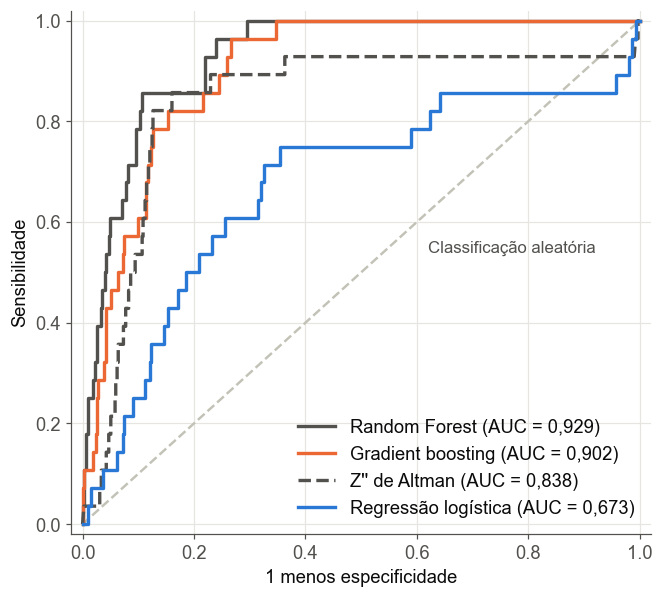

In [39]:
fig, ax = plt.subplots(figsize=(6.2, 5.6))
cores = {"Regressão logística": AZUL, "Random forest": AQUA,
         "Gradient boosting": LARANJA, "Z'' de Altman": CINZA}

ax.plot([0, 1], [0, 1], linestyle="--", color=CINZA_CLARO, linewidth=1.6, zorder=1)
ax.text(0.62, 0.54, "Classificação aleatória", color=CINZA, fontsize=11, rotation=0)

for nome in desempenho["Modelo"]:
    p = predicoes[nome]
    fpr, tpr, _ = roc_curve(y_teste, p)
    auc = detalhe[nome]["AUC-ROC"]
    estilo = "--" if nome == "Z'' de Altman" else "-"
    ax.plot(fpr, tpr, color=cores.get(nome, CINZA), linewidth=2.2, linestyle=estilo,
            label=f"{nome} (AUC = {virgula(auc)})", zorder=3)

ax.set_xlabel("1 menos especificidade")
ax.set_ylabel("Sensibilidade")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.02)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="lower right")
fig.tight_layout()

salvar_figura(fig, 13, "Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman "
                       "no conjunto de teste temporal")
plt.show()

### 9.2 Figura 14, curvas de precisão e revocação

Sob desfecho raro, a curva ROC pode transmitir impressão otimista, conforme Saito e Rehmsmeier
(2015). A curva de precisão e revocação é apresentada porque a linha de referência dela é a
prevalência, e não a diagonal.


[salvo] fig14.png
------------------------------------------------------------------------------
Figura 14. Curvas de precisão e revocação dos modelos e do escore Z'' de Altman no conjunto de teste temporal
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


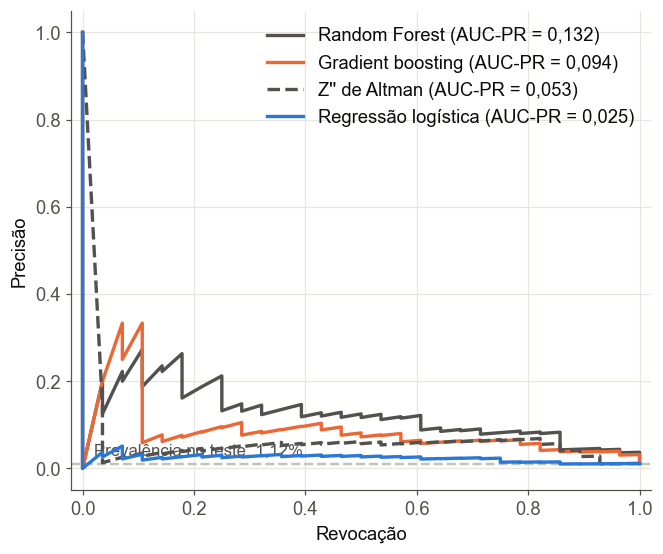

In [40]:
fig, ax = plt.subplots(figsize=(6.2, 5.2))
prevalencia = y_teste.mean()
ax.axhline(prevalencia, linestyle="--", color=CINZA_CLARO, linewidth=1.6, zorder=1)
ax.text(0.02, prevalencia + 0.02, f"Prevalência no teste, {prevalencia:.2%}".replace(".", ","),
        color=CINZA, fontsize=11)

for nome in desempenho["Modelo"]:
    p = predicoes[nome]
    prec, rec, _ = precision_recall_curve(y_teste, p)
    ap = detalhe[nome]["AUC-PR"]
    estilo = "--" if nome == "Z'' de Altman" else "-"
    ax.plot(rec, prec, color=cores.get(nome, CINZA), linewidth=2.2, linestyle=estilo,
            label=f"{nome} (AUC-PR = {virgula(ap)})", zorder=3)

ax.set_xlabel("Revocação")
ax.set_ylabel("Precisão")
ax.set_xlim(-0.02, 1.02)
ax.grid(True, zorder=0)
ax.set_axisbelow(True)
ax.legend(loc="upper right")
fig.tight_layout()

salvar_figura(fig, 14, "Curvas de precisão e revocação dos modelos e do escore Z'' de Altman no "
                       "conjunto de teste temporal")
plt.show()

## 10. Comparação com a linha de base

O critério foi fixado antes da obtenção das métricas: ganho de AUC inferior a 0,03 sobre o escore
Z'' é tratado como equivalência prática. A comparação é feita duas vezes, contra o valor de 0,705
publicado na Tabela 4 do artigo, calculado sobre a amostra completa, e contra o Z'' recalculado
neste mesmo conjunto de teste, que é a comparação metodologicamente correta.

O delta pareado por reamostragem responde a uma pergunta diferente e mais exigente: em quantas
reamostragens o modelo supera a linha de base quando ambos enfrentam exatamente as mesmas
companhias.

In [41]:
def delta_pareado(y, p_modelo, p_base, grupos, n=N_BOOTSTRAP, semente=SEMENTE):
    rng = np.random.default_rng(semente)
    unicos = np.unique(grupos)
    indice = {g: np.where(grupos == g)[0] for g in unicos}
    deltas = []
    for _ in range(n):
        sorteados = rng.choice(unicos, size=len(unicos), replace=True)
        pos = np.concatenate([indice[g] for g in sorteados])
        yb = y[pos]
        if len(np.unique(yb)) < 2:
            continue
        deltas.append(roc_auc_score(yb, p_modelo[pos]) - roc_auc_score(yb, p_base[pos]))
    if not deltas:
        return np.nan, np.nan, np.nan, np.nan
    deltas = np.array(deltas)
    return (float(deltas.mean()), float(np.percentile(deltas, 2.5)),
            float(np.percentile(deltas, 97.5)), float((deltas > 0).mean()))

tem_base = "Z'' de Altman" in predicoes
base_teste = detalhe["Z'' de Altman"]["AUC-ROC"] if tem_base else np.nan

linhas = []
for nome in [m for m in desempenho["Modelo"] if m != "Z'' de Altman"]:
    auc = detalhe[nome]["AUC-ROC"]
    d_artigo = auc - BASELINE_ARTIGO
    if tem_base:
        d, li, ls, prob = delta_pareado(y_teste, predicoes[nome], predicoes["Z'' de Altman"], g_teste)
    else:
        d, li, ls, prob = (np.nan,) * 4
    if np.isnan(d):
        veredito = "não avaliável"
    elif d >= GANHO_MINIMO_RELEVANTE and li > 0:
        veredito = "ganho relevante"
    elif d >= GANHO_MINIMO_RELEVANTE:
        veredito = "ganho pontual relevante, intervalo cruza zero"
    else:
        veredito = "equivalência prática"
    linhas.append({
        "Modelo": nome,
        "AUC-ROC do modelo": auc,
        "AUC-ROC do Z'' no teste": base_teste,
        "Delta sobre o Z'' no teste": d,
        "IC95 inferior": li,
        "IC95 superior": ls,
        "Reamostragens favoráveis": prob,
        "Delta sobre 0,705 do artigo": d_artigo,
        "Veredito pelo critério de 0,03": veredito,
    })

comparacao = pd.DataFrame(linhas)
tab_comparacao = comparacao.copy()
for c in tab_comparacao.columns[1:-1]:
    tab_comparacao[c] = tab_comparacao[c].round(3)

salvar_tabela(tab_comparacao, 12,
              "Comparação dos modelos com a linha de base do escore Z'' de Altman")
print(tab_comparacao.to_string(index=False))


[salvo] tab12.csv
------------------------------------------------------------------------------
Tabela 12. Comparação dos modelos com a linha de base do escore Z'' de Altman
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------
             Modelo  AUC-ROC do modelo  AUC-ROC do Z'' no teste  Delta sobre o Z'' no teste  IC95 inferior  IC95 superior  Reamostragens favoráveis  Delta sobre 0,705 do artigo                Veredito pelo critério de 0,03
      Random Forest              0.929                    0.838                       0.087          0.005          0.220                     0.983                        0.224                               ganho relevante
  Gradient boosting              0.902                    0.838                       0.061         -0.025          0.195                     0.873                        0.197 ganho pontual relevante, intervalo cruza zero
Regressão logística              0.6


[salvo] fig15.png
------------------------------------------------------------------------------
Figura 15. Diferença de AUC-ROC entre cada modelo e o escore Z'' de Altman, com intervalos de 95% por reamostragem de companhias
Nota: a linha tracejada marca o limite de 0,03 fixado antes da obtenção dos resultados.
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


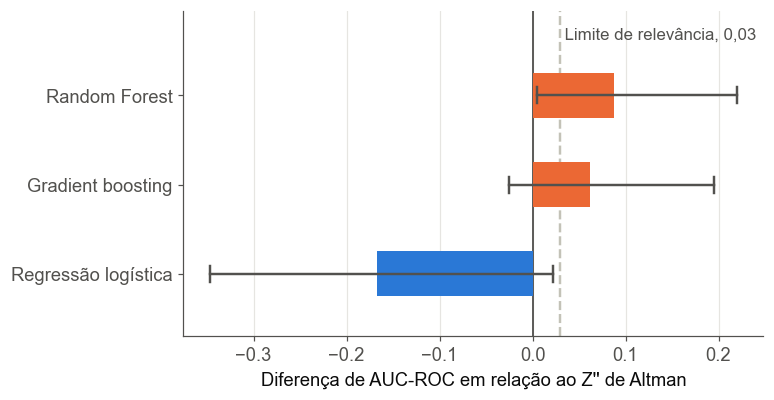

In [42]:
fig, ax = plt.subplots(figsize=(7.2, 3.8))
nomes = comparacao["Modelo"].tolist()[::-1]
valores = comparacao["Delta sobre o Z'' no teste"].tolist()[::-1]
inf = comparacao["IC95 inferior"].tolist()[::-1]
sup = comparacao["IC95 superior"].tolist()[::-1]

y_pos = np.arange(len(nomes))
cores_barras = [LARANJA if (v is not None and not np.isnan(v) and v >= GANHO_MINIMO_RELEVANTE)
                else AZUL for v in valores]
ax.barh(y_pos, valores, color=cores_barras, height=0.5, zorder=3)
for i, (a, b) in enumerate(zip(inf, sup)):
    if not np.isnan(a):
        ax.plot([a, b], [i, i], color=CINZA, linewidth=1.6, zorder=4)
        ax.plot([a, a], [i - 0.09, i + 0.09], color=CINZA, linewidth=1.6, zorder=4)
        ax.plot([b, b], [i - 0.09, i + 0.09], color=CINZA, linewidth=1.6, zorder=4)

ax.axvline(0, color=CINZA, linewidth=1.2, zorder=2)
ax.axvline(GANHO_MINIMO_RELEVANTE, color=CINZA_CLARO, linestyle="--", linewidth=1.6, zorder=2)
ax.set_ylim(-0.7, len(nomes) - 0.05)
ax.text(GANHO_MINIMO_RELEVANTE, len(nomes) - 0.32,
        f" Limite de relevância, {virgula(GANHO_MINIMO_RELEVANTE, 2)}",
        color=CINZA, fontsize=11, ha="left", va="center")
ax.set_yticks(y_pos)
ax.set_yticklabels(nomes)
ax.set_xlabel("Diferença de AUC-ROC em relação ao Z'' de Altman")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()

salvar_figura(fig, 15, "Diferença de AUC-ROC entre cada modelo e o escore Z'' de Altman, com "
                       "intervalos de 95% por reamostragem de companhias",
              nota="Nota: a linha tracejada marca o limite de 0,03 fixado antes da obtenção dos resultados.")
plt.show()

## 11. Contribuição das preditoras

Os valores de Shapley (Lundberg e Lee, 2017) são calculados sobre o modelo de melhor desempenho
entre os três. Quando a biblioteca não está disponível, o caderno recorre à importância por
permutação, que responde à mesma pergunta de forma mais grosseira, e registra a substituição.

A importância é calculada no conjunto de teste apenas para descrever o modelo já congelado. Nenhuma
preditora é adicionada ou removida depois desta etapa.

In [43]:
melhor = [m for m in desempenho["Modelo"] if m != "Z'' de Altman"][0]
modelo_melhor = ajustados[melhor]
print(f"modelo de melhor desempenho: {melhor}")
print(f"AUC-ROC {virgula(detalhe[melhor]['AUC-ROC'])}")

valores_shap = None
metodo_importancia = "permutação"

if TEM_SHAP and melhor != "Regressão logística":
    try:
        estimador = modelo_melhor
        explicador = shap.TreeExplainer(estimador)
        valores_shap = explicador.shap_values(X_teste)
        if isinstance(valores_shap, list):
            valores_shap = valores_shap[1]
        if getattr(valores_shap, "ndim", 2) == 3:
            valores_shap = valores_shap[:, :, 1]
        metodo_importancia = "Shapley"
        print("valores de Shapley calculados")
    except Exception as erro:
        print("falha no calculo de Shapley:", erro)
        valores_shap = None

if valores_shap is None:
    perm = permutation_importance(modelo_melhor, X_teste, y_teste, n_repeats=20,
                                  random_state=SEMENTE, scoring="roc_auc")
    importancia = pd.Series(perm.importances_mean, index=PREDITORAS)
    desvio = pd.Series(perm.importances_std, index=PREDITORAS)
    print(f"importancia por permutacao calculada sobre {len(X_teste)} observacoes")
else:
    importancia = pd.Series(np.abs(valores_shap).mean(axis=0), index=PREDITORAS)
    desvio = pd.Series(np.abs(valores_shap).std(axis=0), index=PREDITORAS)

importancia = importancia.sort_values(ascending=False)
print(f"\nmetodo adotado: {metodo_importancia}")

modelo de melhor desempenho: Random Forest
AUC-ROC 0,929
valores de Shapley calculados

metodo adotado: Shapley


In [44]:
direcao = []
for c in PREDITORAS:
    if valores_shap is not None:
        i = PREDITORAS.index(c)
        v = X_teste[c].to_numpy()
        s = valores_shap[:, i]
        if np.std(v) > 0 and np.std(s) > 0:
            r = np.corrcoef(v, s)[0, 1]
        else:
            r = np.nan
    else:
        m = teste[ALVO] == 1
        if m.sum() > 0 and (~m).sum() > 0:
            r = np.sign(X_teste.loc[m.to_numpy(), c].median()
                        - X_teste.loc[~m.to_numpy(), c].median())
        else:
            r = np.nan
    if np.isnan(r):
        direcao.append("não determinada")
    elif r > 0:
        direcao.append("valor mais alto aumenta o risco estimado")
    else:
        direcao.append("valor mais alto reduz o risco estimado")

tab_import = pd.DataFrame({
    "Preditora": [ROTULOS.get(c, c) for c in importancia.index],
    "Importância média": importancia.values.round(4),
    "Dispersão": desvio.reindex(importancia.index).values.round(4),
    "Direção do efeito": [direcao[PREDITORAS.index(c)] for c in importancia.index],
})

salvar_tabela(tab_import, 13,
              f"Contribuição das preditoras no modelo de melhor desempenho, método de {metodo_importancia}")
print(tab_import.to_string(index=False))


[salvo] tab13.csv
------------------------------------------------------------------------------
Tabela 13. Contribuição das preditoras no modelo de melhor desempenho, método de Shapley
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------
                    Preditora  Importância média  Dispersão                        Direção do efeito
          Endividamento geral             0.0783     0.0255 valor mais alto aumenta o risco estimado
           Cobertura de juros             0.0699     0.0300   valor mais alto reduz o risco estimado
            Liquidez imediata             0.0562     0.0161   valor mais alto reduz o risco estimado
           Margem operacional             0.0506     0.0285   valor mais alto reduz o risco estimado
         Crescimento do ativo             0.0396     0.0169 valor mais alto aumenta o risco estimado
   Retorno antes dos tributos             0.0349     0.0148   valor mais alto reduz o ri


[salvo] fig16.png
------------------------------------------------------------------------------
Figura 16. Contribuição das preditoras no modelo random forest, método de Shapley
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


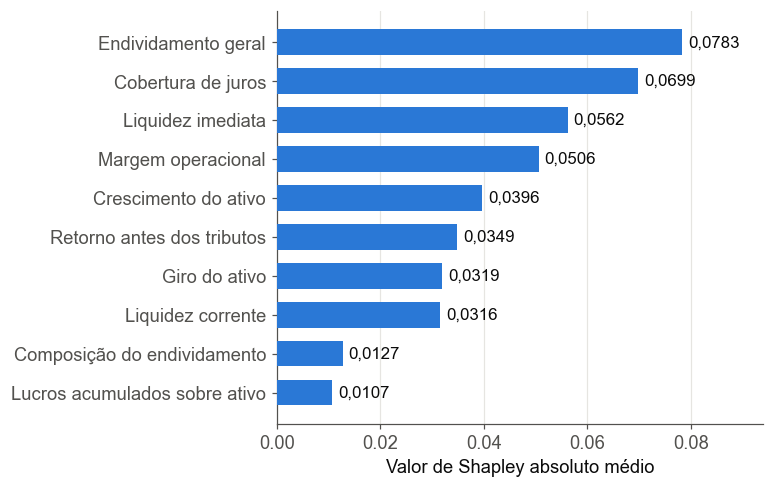

In [45]:
fig, ax = plt.subplots(figsize=(7.2, 4.6))
ordem = importancia.sort_values()
rotulos = [ROTULOS.get(c, c) for c in ordem.index]
barras = ax.barh(rotulos, ordem.values, color=AZUL, height=0.66, zorder=3)
limite = ordem.max() if ordem.max() > 0 else 1
for b, v in zip(barras, ordem.values):
    ax.text(v + limite * 0.015, b.get_y() + b.get_height() / 2,
            virgula(v, 4), va="center", fontsize=11)
ax.set_xlim(0, limite * 1.20)
ax.set_xlabel("Importância média" if valores_shap is None
              else "Valor de Shapley absoluto médio")
ax.xaxis.grid(True, zorder=0)
ax.set_axisbelow(True)
fig.tight_layout()

salvar_figura(fig, 16, f"Contribuição das preditoras no modelo {melhor.lower()}, método de "
                       f"{metodo_importancia}")
plt.show()

## 12. Análise dos erros

A matriz de confusão usa o limiar do ponto de Youden. A separação entre falsos negativos e falsos
positivos importa porque os dois erros têm custos diferentes: deixar de identificar uma companhia
que vai pedir recuperação judicial não é equivalente a sinalizar uma companhia que não vai.


[salvo] fig17.png
------------------------------------------------------------------------------
Figura 17. Matriz de confusão do modelo random forest no conjunto de teste, limiar do ponto de Youden
Nota: limiar de 0,467.
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


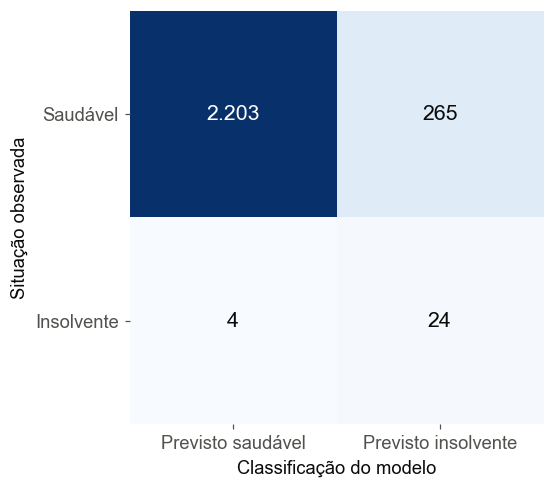


verdadeiros negativos 2203
falsos positivos      265
falsos negativos      4
verdadeiros positivos 24


In [46]:
limiar_melhor = detalhe[melhor]["Limiar"]
p_melhor = predicoes[melhor]
pred_melhor = (p_melhor >= limiar_melhor).astype(int)
tn, fp, fn, tp = confusion_matrix(y_teste, pred_melhor, labels=[0, 1]).ravel()

fig, ax = plt.subplots(figsize=(5.4, 4.6))
matriz = np.array([[tn, fp], [fn, tp]])
im = ax.imshow(matriz, cmap="Blues", vmin=0, vmax=matriz.max())
ax.set_xticks([0, 1]); ax.set_xticklabels(["Previsto saudável", "Previsto insolvente"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Saudável", "Insolvente"])
for i in range(2):
    for j in range(2):
        v = matriz[i, j]
        ax.text(j, i, f"{v:,}".replace(",", "."), ha="center", va="center", fontsize=14,
                color="white" if v > matriz.max() * 0.55 else "#0b0b0b")
ax.set_xlabel("Classificação do modelo")
ax.set_ylabel("Situação observada")
for lado in ("top", "right", "left", "bottom"):
    ax.spines[lado].set_visible(False)
ax.grid(False)
fig.tight_layout()

salvar_figura(fig, 17, f"Matriz de confusão do modelo {melhor.lower()} no conjunto de teste, "
                       f"limiar do ponto de Youden",
              nota=f"Nota: limiar de {virgula(limiar_melhor)}.")
plt.show()

print(f"\nverdadeiros negativos {tn}")
print(f"falsos positivos      {fp}")
print(f"falsos negativos      {fn}")
print(f"verdadeiros positivos {tp}")


[salvo] fig18.png
------------------------------------------------------------------------------
Figura 18. Distribuição das probabilidades estimadas por situação observada no conjunto de teste
Nota: escalas verticais independentes, dada a diferença de tamanho entre os grupos.
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------


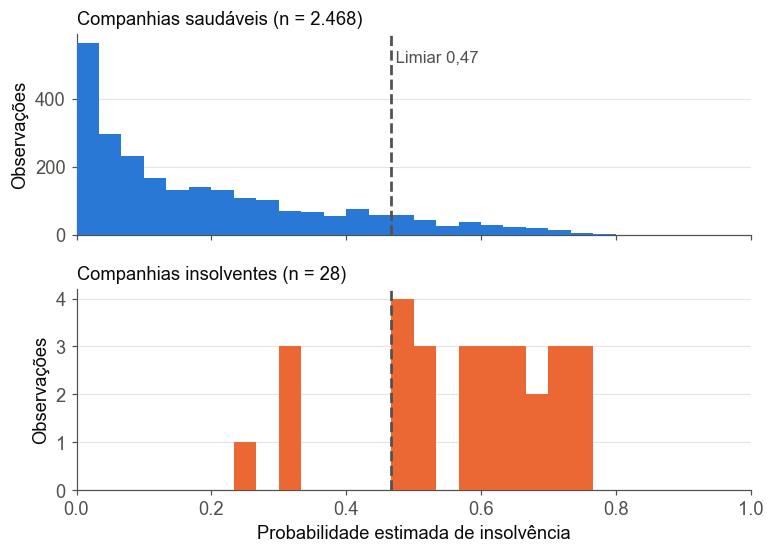

In [47]:
fig, eixos = plt.subplots(2, 1, figsize=(7.2, 5.2), sharex=True)
bins = np.linspace(0, 1, 31)
grupos = [("Companhias saudáveis", p_melhor[y_teste == 0], AZUL),
          ("Companhias insolventes", p_melhor[y_teste == 1], LARANJA)]

for ax, (titulo, valores_p, cor) in zip(eixos, grupos):
    ax.hist(valores_p, bins=bins, color=cor, zorder=3)
    ax.axvline(limiar_melhor, color=CINZA, linestyle="--", linewidth=1.8, zorder=4)
    ax.set_ylabel("Observações")
    ax.set_title(f"{titulo} (n = {len(valores_p):,})".replace(",", "."),
                 loc="left", fontsize=12)
    ax.yaxis.grid(True, zorder=0)
    ax.set_axisbelow(True)

eixos[0].text(limiar_melhor, eixos[0].get_ylim()[1] * 0.92,
              f" Limiar {virgula(limiar_melhor, 2)}", color=CINZA, fontsize=11, va="top")
eixos[1].set_xlabel("Probabilidade estimada de insolvência")
eixos[1].set_xlim(0, 1)
fig.tight_layout()

salvar_figura(fig, 18, "Distribuição das probabilidades estimadas por situação observada no "
                       "conjunto de teste",
              nota="Nota: escalas verticais independentes, dada a diferença de tamanho entre os grupos.")
plt.show()

In [48]:
erros = teste.copy()
erros["probabilidade"] = p_melhor
erros["previsto"] = pred_melhor
erros["tipo"] = np.select(
    [(erros[ALVO] == 1) & (erros["previsto"] == 1),
     (erros[ALVO] == 1) & (erros["previsto"] == 0),
     (erros[ALVO] == 0) & (erros["previsto"] == 1)],
    ["Verdadeiro positivo", "Falso negativo", "Falso positivo"],
    default="Verdadeiro negativo")

perfil = (erros.groupby("tipo")[PREDITORAS].median().T)
perfil.index = [ROTULOS.get(c, c) for c in perfil.index]
perfil.index.name = "Indicador (mediana)"
colunas = [c for c in ["Verdadeiro positivo", "Falso negativo", "Falso positivo",
                       "Verdadeiro negativo"] if c in perfil.columns]
perfil = perfil[colunas].round(3)

salvar_tabela(perfil, 14,
              "Perfil mediano das preditoras por tipo de acerto e de erro no conjunto de teste",
              indice=True)
print(erros["tipo"].value_counts().to_string())
print()
print(perfil.to_string())


[salvo] tab14.csv
------------------------------------------------------------------------------
Tabela 14. Perfil mediano das preditoras por tipo de acerto e de erro no conjunto de teste
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------
tipo
Verdadeiro negativo    2203
Falso positivo          265
Verdadeiro positivo      24
Falso negativo            4

tipo                           Verdadeiro positivo  Falso negativo  Falso positivo  Verdadeiro negativo
Indicador (mediana)                                                                                    
Liquidez corrente                            0.487           1.133           0.613                1.568
Liquidez imediata                            0.064           0.212           0.062                0.556
Endividamento geral                          1.139           0.685           1.040                0.631
Composição do endividamento                  0.586    

In [49]:
casos = erros[erros["tipo"].isin(["Falso negativo", "Falso positivo"])].copy()
casos = casos.sort_values(["tipo", "probabilidade"], ascending=[True, False])

tab_casos = pd.DataFrame({
    "Tipo": casos["tipo"].values,
    "Companhia": casos["DENOM_CIA"].astype(str).str.title().values,
    "Exercício": casos["ANO"].astype(int).values,
    "UF": casos["uf"].fillna("").values,
    "Probabilidade estimada": casos["probabilidade"].round(3).values,
})

if len(tab_casos) > 40:
    print(f"{len(tab_casos)} casos classificados incorretamente, exibindo os 40 de maior probabilidade")
    tab_casos = tab_casos.head(40)

salvar_tabela(tab_casos, 15,
              "Companhias classificadas incorretamente pelo modelo de melhor desempenho no "
              "conjunto de teste")
print(tab_casos.to_string(index=False))

269 casos classificados incorretamente, exibindo os 40 de maior probabilidade

[salvo] tab15.csv
------------------------------------------------------------------------------
Tabela 15. Companhias classificadas incorretamente pelo modelo de melhor desempenho no conjunto de teste
Fonte: Resultados originais da pesquisa
------------------------------------------------------------------------------
          Tipo                                         Companhia  Exercício UF  Probabilidade estimada
Falso negativo               Fasa S.A. - Em Recuperação Judicial       2025 SP                   0.326
Falso negativo         Uptick Participacoes S.A. - Em Liquidação       2023 RJ                   0.325
Falso negativo            Bombril S.A. - Em Recuperação Judicial       2023 SP                   0.301
Falso negativo Intercement Brasil S.A. - Em Recuperação Judicial       2022 SP                   0.258
Falso positivo                                  Ammo Varejo S.A.       2024 SP       

## 13. Veredito pelo critério pré-registrado

O bloco abaixo aplica mecanicamente a regra fixada antes da obtenção dos resultados e imprime o
parágrafo de conclusão pronto para o artigo. O objetivo é impedir que o critério seja reinterpretado
depois de conhecidos os números.

In [50]:
linha_melhor = comparacao[comparacao["Modelo"] == melhor].iloc[0]
d = linha_melhor["Delta sobre o Z'' no teste"]
auc_melhor = linha_melhor["AUC-ROC do modelo"]

print("=" * 78)
print("VEREDITO")
print("=" * 78)
print(f"Melhor modelo                    {melhor}")
print(f"AUC-ROC no teste                 {virgula(auc_melhor)}")
print(f"AUC-ROC do Z'' no mesmo teste    {virgula(base_teste)}")
print(f"Delta pareado                    {virgula(d)}")
print(f"IC95 do delta                    [{virgula(linha_melhor['IC95 inferior'])}, "
      f"{virgula(linha_melhor['IC95 superior'])}]")
print(f"Critério pré-registrado          ganho de {virgula(GANHO_MINIMO_RELEVANTE, 2)}")
print(f"Classificação                    {linha_melhor['Veredito pelo critério de 0,03'].upper()}")
print("=" * 78)

if str(linha_melhor["Veredito pelo critério de 0,03"]).startswith("ganho relevante"):
    frase = (f"O modelo {melhor.lower()} superou a linha de base do escore Z'' de Altman em "
             f"{virgula(d)} de área sob a curva ROC, com intervalo de 95% entre "
             f"{virgula(linha_melhor['IC95 inferior'])} e {virgula(linha_melhor['IC95 superior'])}. "
             f"O ganho excede o limite de {virgula(GANHO_MINIMO_RELEVANTE, 2)} fixado antes da "
             f"obtenção dos resultados e o intervalo não contém zero, de modo que a superioridade "
             f"do método é sustentada pelos dados.")
elif str(linha_melhor["Veredito pelo critério de 0,03"]).startswith("ganho pontual"):
    frase = (f"O modelo {melhor.lower()} apresentou ganho pontual de {virgula(d)} sobre o escore "
             f"Z'' de Altman, acima do limite de {virgula(GANHO_MINIMO_RELEVANTE, 2)}, mas o "
             f"intervalo de 95% entre {virgula(linha_melhor['IC95 inferior'])} e "
             f"{virgula(linha_melhor['IC95 superior'])} contém zero. A evidência é compatível com "
             f"superioridade, porém insuficiente para afirmá-la com a amostra de eventos disponível.")
else:
    frase = (f"O modelo {melhor.lower()} apresentou diferença de {virgula(d)} em relação ao escore "
             f"Z'' de Altman, abaixo do limite de {virgula(GANHO_MINIMO_RELEVANTE, 2)} fixado antes "
             f"da obtenção dos resultados. Pelo critério pré-registrado, o resultado é tratado como "
             f"equivalência prática: os algoritmos de aprendizado de máquina não superaram, nesta "
             f"amostra, uma combinação linear de quatro razões de balanço publicada em 1995.")

print("\nParágrafo para o artigo:\n")
print(frase)

VEREDITO
Melhor modelo                    Random Forest
AUC-ROC no teste                 0,929
AUC-ROC do Z'' no mesmo teste    0,838
Delta pareado                    0,087
IC95 do delta                    [0,005, 0,220]
Critério pré-registrado          ganho de 0,03
Classificação                    GANHO RELEVANTE

Parágrafo para o artigo:

O modelo random forest superou a linha de base do escore Z'' de Altman em 0,087 de área sob a curva ROC, com intervalo de 95% entre 0,005 e 0,220. O ganho excede o limite de 0,03 fixado antes da obtenção dos resultados e o intervalo não contém zero, de modo que a superioridade do método é sustentada pelos dados.


## 14. Exportação

In [51]:
caminho_xlsx = DIR_TAB / "tabelas_do_artigo_modelagem.xlsx"
with pd.ExcelWriter(caminho_xlsx, engine="openpyxl") as escritor:
    for t in TABELAS:
        t["dados"].to_excel(escritor, sheet_name=f"Tabela {t['numero']}",
                            index=t.get("indice", False))
print(f"[salvo] {caminho_xlsx.name} com {len(TABELAS)} tabelas")

indice = pd.DataFrame(
    [{"Tipo": "Figura", "Número": f["numero"], "Arquivo": f["arquivo"], "Título": f["titulo"]}
     for f in FIGURAS]
    + [{"Tipo": "Tabela", "Número": t["numero"], "Arquivo": t["arquivo"], "Título": t["titulo"]}
       for t in TABELAS]
).sort_values(["Tipo", "Número"])

caminho_indice = DIR_TAB / "indice_figuras_tabelas_modelagem.csv"
indice.to_csv(caminho_indice, index=False, encoding="utf-8-sig", sep=";")
print(f"[salvo] {caminho_indice.name}")
print()
print(indice.to_string(index=False))

[salvo] tabelas_do_artigo_modelagem.xlsx com 11 tabelas
[salvo] indice_figuras_tabelas_modelagem.csv

  Tipo  Número   Arquivo                                                                                                                Título
Figura      13 fig13.png              Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman no conjunto de teste temporal
Figura      13 fig13.png              Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman no conjunto de teste temporal
Figura      13 fig13.png              Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman no conjunto de teste temporal
Figura      14 fig14.png                    Curvas de precisão e revocação dos modelos e do escore Z'' de Altman no conjunto de teste temporal
Figura      14 fig14.png                    Curvas de precisão e revocação dos modelos e do escore Z'' de Altman no conjunto de teste temporal
Figura      14 fig14.png                

In [52]:
print("=" * 78)
print("LEGENDAS PRONTAS PARA O ARTIGO")
print("=" * 78)
for f in FIGURAS:
    print(f"\nFigura {f['numero']}. {f['titulo']}")
    print("Fonte: Resultados originais da pesquisa.")
for t in TABELAS:
    print(f"\nTabela {t['numero']}. {t['titulo']}")
    print("Fonte: Resultados originais da pesquisa.")

print("\n" + "=" * 78)
print(f"execucao concluida em {datetime.now():%d/%m/%Y %H:%M}")
print(f"{len(FIGURAS)} figuras e {len(TABELAS)} tabelas")
print("=" * 78)

LEGENDAS PRONTAS PARA O ARTIGO

Figura 13. Curvas ROC dos modelos de aprendizado de máquina e do escore Z'' de Altman no conjunto de teste temporal
Fonte: Resultados originais da pesquisa.

Figura 14. Curvas de precisão e revocação dos modelos e do escore Z'' de Altman no conjunto de teste temporal
Fonte: Resultados originais da pesquisa.

Figura 15. Diferença de AUC-ROC entre cada modelo e o escore Z'' de Altman, com intervalos de 95% por reamostragem de companhias
Fonte: Resultados originais da pesquisa.

Figura 16. Contribuição das preditoras no modelo floresta aleatória, método de Shapley
Fonte: Resultados originais da pesquisa.

Figura 17. Matriz de confusão do modelo floresta aleatória no conjunto de teste, limiar do ponto de Youden
Fonte: Resultados originais da pesquisa.

Figura 18. Distribuição das probabilidades estimadas por situação observada no conjunto de teste
Fonte: Resultados originais da pesquisa.

Figura 13. Curvas ROC dos modelos de aprendizado de máquina e do escor